In [22]:
import h5py
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import bosperrus as bsp
import conntility

In [23]:
FN_MAT = "../reimann_data/connectome_BBP.h5"

In [25]:
M = conntility.ConnectivityMatrix.from_h5(FN_MAT)

In [34]:
node_df = M.vertices

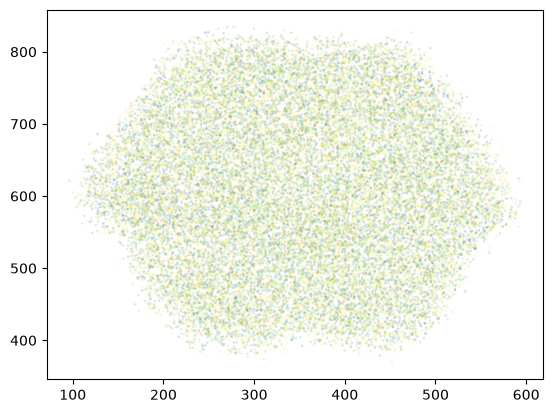

In [52]:
plt.scatter(node_df["x"], node_df["z"], s=1, alpha=0.1, c=node_df["layer"])

In [50]:
node_df["degree"] = np.array(M.dense_matrix.sum(axis=0))[0]

In [53]:
scores = node_df[["degree"]]
coords = node_df[["x", "z"]]

In [56]:
flow = bsp.Flow.from_coords_and_scores(coordinates=coords, scores=scores, distance_fn=bsp.distance_to_alpha_shape, distance_kwargs={"alpha":0.0001})

In [60]:
flow.flow(fits=[bsp.PiecewiseLinearFit, bsp.ConstantFit])

In [70]:
flow.best_fits["degree"].params['piecewise_linear_b']

{'piecewise_linear_b': np.float64(144.7658856775569),
 'piecewise_linear_m': np.float64(1.262992179498502),
 'piecewise_linear_c': np.float64(137.45301682616068)}

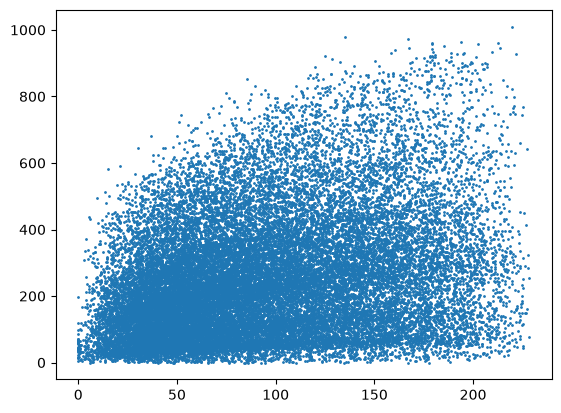

In [66]:
plt.scatter(y=flow.observations["degree"], x=flow.observations["distance_to_alpha_shape"], s=1)

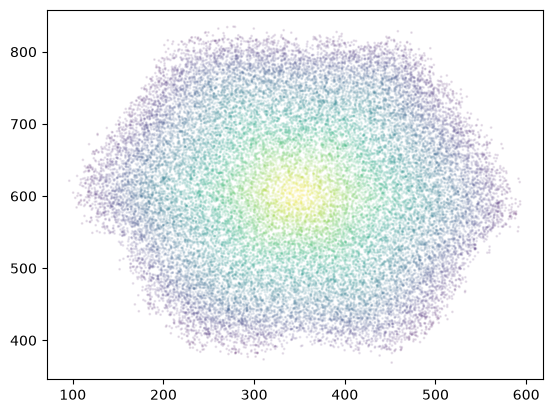

In [67]:
plt.scatter(node_df["x"], node_df["z"], s=1, alpha=0.1, c=flow.observations["distance_to_alpha_shape"])

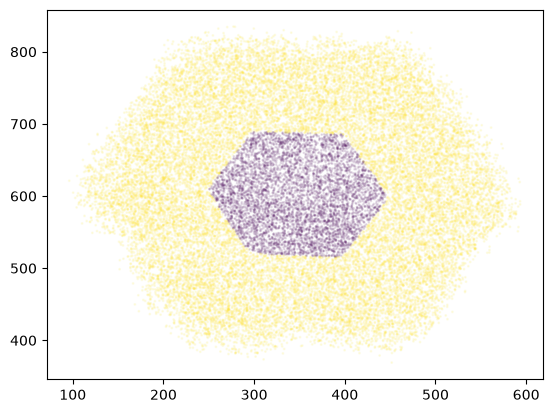

In [71]:
plt.scatter(node_df["x"], node_df["z"], s=1, alpha=0.1, c=flow.observations["distance_to_alpha_shape"]<flow.best_fits["degree"].params['piecewise_linear_b'])